Things to Do before running the cells:

1. Change the path in variable "image_path" to path which points to trimmed sentinel 2 TCI tif.
2. Change the path in the follwing paths.
   "trimmed_tif_path" = Path of trimmed huron county tiff
   "b4_path" = Path of the sentinel 2 band 4
   "b8_path" = Path of the sentinel 2 band 8
   

In [4]:
import numpy as np
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
import matplotlib.pyplot as plt
from shapely.geometry import box
import cv2
from skimage.morphology import remove_small_objects
from scipy.ndimage import distance_transform_edt

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 7154, 'height': 4354, 'count': 3, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 17N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32617"]]'), 'transform': Affine(10.0, 0.0, 299110.0,
       0.0, -10.0, 4881390.0)}


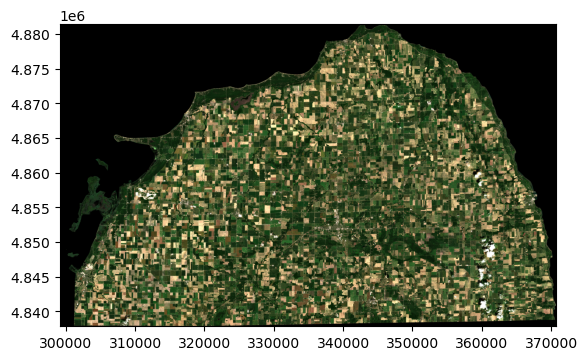

In [5]:
# Load the TIFF image and print its metadata
image_path = "C:/Users/vbopp/Downloads/trimmed_S2A_17TLJ_20190714_0_L2A_TCI.tif"
with rasterio.open(image_path) as src:
    print(src.meta)  
    show(src)  


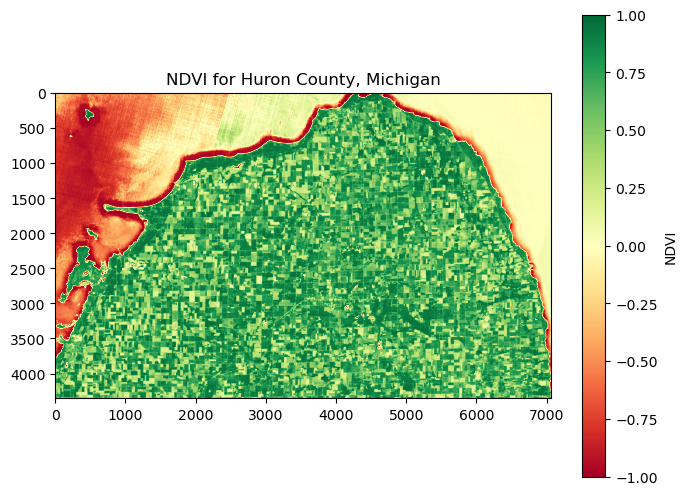

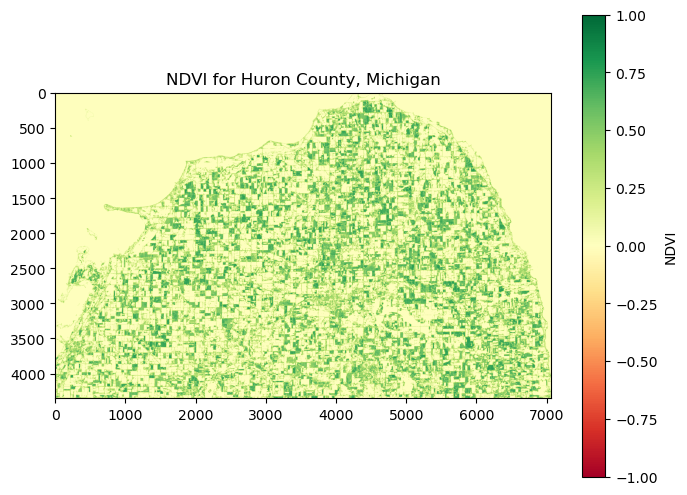

In [6]:

# Load the Trimmed Huron County TIFF to Get Bounds
trimmed_tif_path = "C:/Users/vbopp/Downloads/trimmed_S2A_17TLJ_20190714_0_L2A_TCI.tif"

with rasterio.open(trimmed_tif_path) as src:
    huron_bounds = src.bounds  # Get bounding box of the trimmed image
    huron_crs = src.crs  # Store CRS

#  Define a Shapely Polygon for Cropping the huron county
huron_geometry = [box(*huron_bounds)] 

# Function to Clip a Band Using the Huron County Boundary
def clip_band(band_path, geometry):
    with rasterio.open(band_path) as src:
        clipped_band, clipped_transform = mask(src, geometry, crop=True)
        profile = src.profile 
        profile.update({
            "height": clipped_band.shape[1], 
            "width": clipped_band.shape[2], 
            "transform": clipped_transform
        })
    return clipped_band[0].astype(float), profile  # Converting to float for NDVI calculation

# Clip B4 (Red) and B8 (NIR) Using the Trimmed Extent
b4_path = "C:/Users/vbopp/Downloads/B04.tif"  
b8_path = "C:/Users/vbopp/Downloads/B08.tif"  

b4_clipped, b4_profile = clip_band(b4_path, huron_geometry)
b8_clipped, b8_profile = clip_band(b8_path, huron_geometry)

# Scaling the Bands to Reflectance Values
b4_clipped /= 10000.0
b8_clipped /= 10000.0

#  Calculating NDVI Using Clipped Bands
ndvi = (b8_clipped - b4_clipped) / (b8_clipped + b4_clipped + 1e-6)  
ndvi = np.clip(ndvi, -1, 1)  

#Clipped NDVI
plt.figure(figsize=(8, 6))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("NDVI for Huron County, Michigan")
plt.show()

ndvi[b8_clipped < 0.1] = 0  # Masking low-reflectance areas (water, clouds) as we donot need
#them for segmentation

# Mask NDVI to Keep Only Crop Areas (Set Others to 0)
ndvi[(ndvi < 0.4) | (ndvi > 0.8)] = 0 


#  final Clipped NDVI
plt.figure(figsize=(8, 6))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("NDVI for Huron County, Michigan")
plt.show()

In [7]:

# Normalize NDVI (Convert to 0-255 for OpenCV)
ndvi_normalized = cv2.normalize(ndvi, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

print("Min NDVI:", np.min(ndvi_normalized), "Max NDVI:", np.max(ndvi_normalized))



Min NDVI: 0 Max NDVI: 254


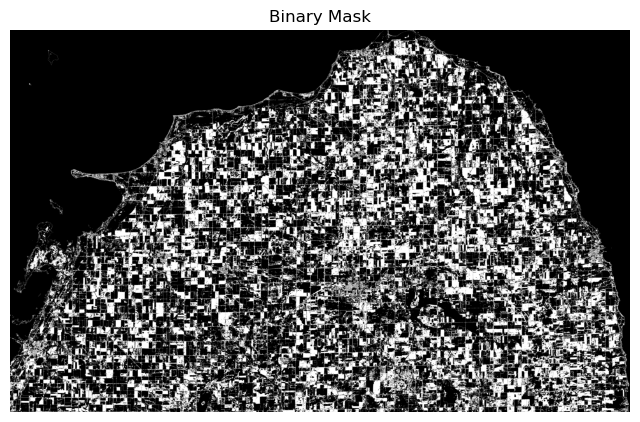

In [8]:
# Thresholding to Create a Binary Mask
_, binary_mask = cv2.threshold(ndvi_normalized, 0, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(8, 8))
plt.imshow(binary_mask, cmap='gray')
plt.title("Binary Mask")
plt.axis("off")
plt.show()



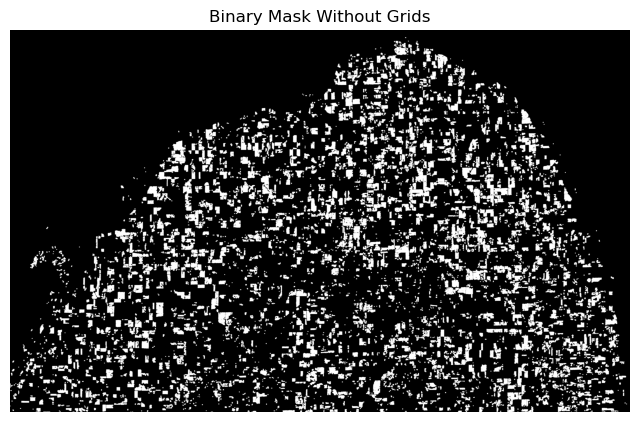

In [9]:
# Use a larger kernel for grid-like artifacts
grid_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

# Use an opening operation to remove thin grid-like structures
binary_mask_no_grid = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, grid_kernel, iterations=2)

plt.figure(figsize=(8, 8))
plt.imshow(binary_mask_no_grid, cmap='gray')
plt.title("Binary Mask Without Grids")
plt.axis("off")
plt.show()


Before removal: 4498 objects
After removal: 1116 objects


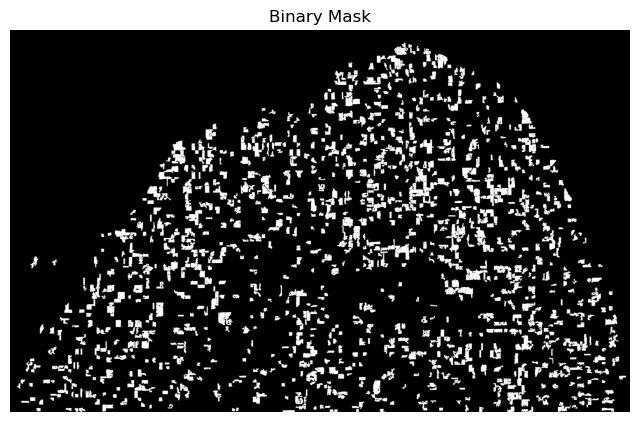

In [10]:
from skimage.measure import label

# Label before removal
labels_before = label(binary_mask_no_grid)
num_objects_before = len(np.unique(labels_before))  # Count unique labels (objects)

# Label after removal
binary_mask_no_grid = remove_small_objects(binary_mask_no_grid.astype(bool), min_size=1000).astype(np.uint8) * 255
labels_after = label(binary_mask_no_grid)
num_objects_after = len(np.unique(labels_after))

print(f"Before removal: {num_objects_before} objects")
print(f"After removal: {num_objects_after} objects")
plt.figure(figsize=(8, 8))
plt.imshow(binary_mask_no_grid, cmap='gray')
plt.title("Binary Mask")
plt.axis("off")
plt.show()


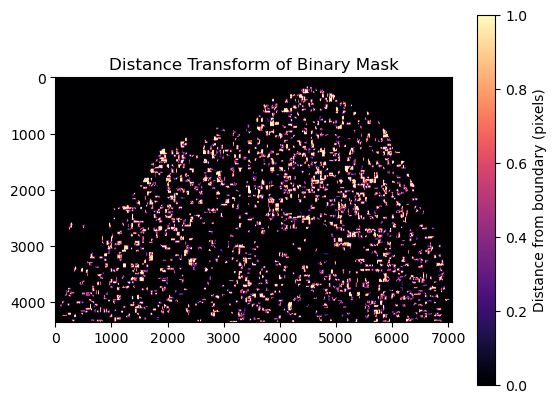

In [11]:
# Compute Distance Transform
dist_transform = distance_transform_edt(binary_mask_no_grid)
dist_thresh = dist_transform > 3

plt.imshow(dist_thresh, cmap='magma')
plt.colorbar(label="Distance from boundary (pixels)")
plt.title("Distance Transform of Binary Mask")
plt.show()

In [12]:
# Convert boolean mask to float32 or uint8 before normalization
dist_thresh_float = dist_thresh.astype(np.float32)

# Normalize to 0–255
dist_normalized = cv2.normalize(dist_thresh_float, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


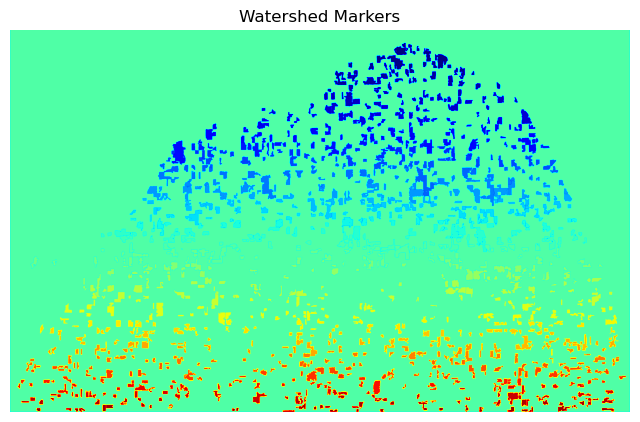

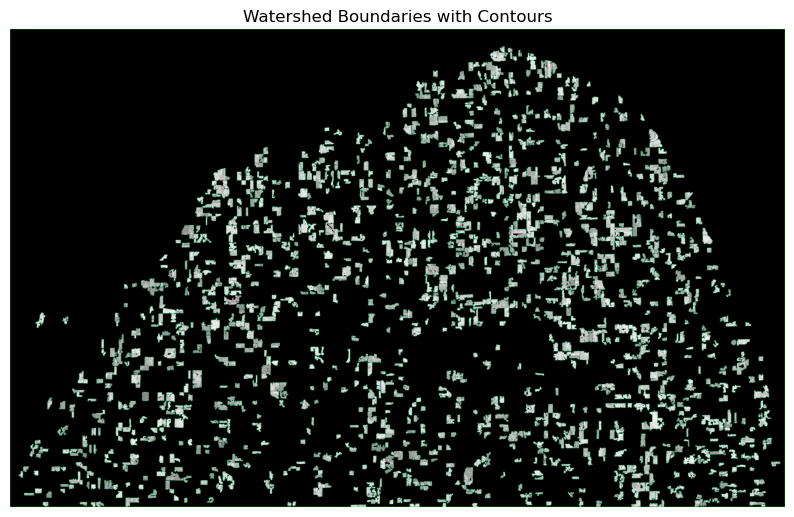

In [13]:


# Threshold & Connected Components (already done)
_, markers = cv2.threshold(dist_normalized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
markers = cv2.connectedComponents(markers.astype(np.uint8))[1]

#  Mask the NDVI image
ndvi_masked = cv2.bitwise_and(ndvi_normalized, ndvi_normalized, mask=binary_mask_no_grid.astype(np.uint8))

#Convert to RGB for watershed input
ndvi_rgb = cv2.cvtColor(ndvi_masked, cv2.COLOR_GRAY2BGR)

# Apply watershed
cv2.watershed(ndvi_rgb, markers)

# Drawing Red Boundaries where watershed marked borders (-1)
boundaries = (markers == -1)
ndvi_rgb[boundaries] = [255, 0, 0]

# Extract contours from the watershed output
# Convert marker boundaries to uint8 for contour finding
boundary_mask = np.zeros_like(markers, dtype=np.uint8)
boundary_mask[boundaries] = 255

# Dilate the thin boundary lines
kernel = np.ones((3, 3), np.uint8)
boundary_mask_dilated = cv2.dilate(boundary_mask, kernel, iterations=1)

# Find contours
contours, _ = cv2.findContours(boundary_mask_dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

#Drawinng contours on a blank image or overlay
contour_overlay = ndvi_rgb.copy()
cv2.drawContours(contour_overlay, contours, -1, (0, 255, 0), 1) 

#Visualizing watershed markers
plt.figure(figsize=(8, 6))
plt.imshow(markers, cmap="jet") 
plt.title("Watershed Markers")
plt.axis("off")
plt.show()


# Show result
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(contour_overlay, cv2.COLOR_BGR2RGB))
plt.title("Watershed Boundaries with Contours")
plt.axis('off')
plt.show()


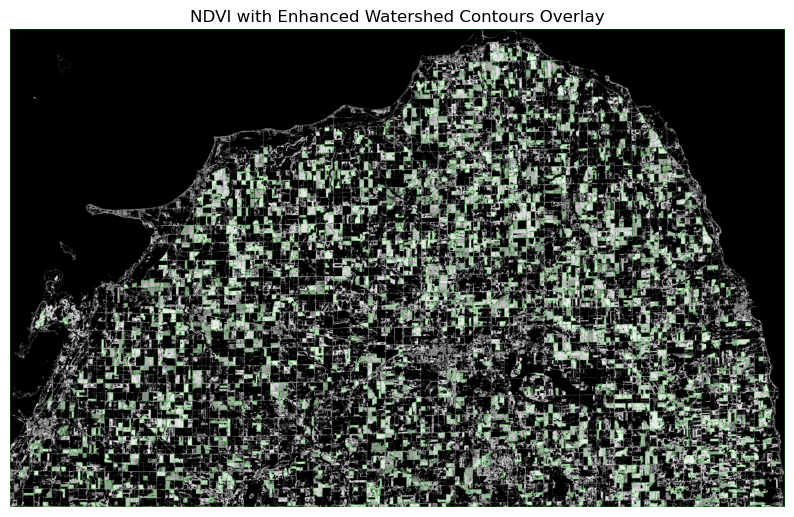

In [14]:
ndvi_overlay = cv2.cvtColor(ndvi_normalized, cv2.COLOR_GRAY2BGR)

# Use white or red contours (white shown here)
contour_color = (0, 255, 0)  # Try (255, 0, 0) for bright red

#ndvi_dimmed = (ndvi_overlay * 0.6).astype(np.uint8)


cv2.drawContours(ndvi_overlay, contours, -1, contour_color, thickness=1)

# Show overlay result
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(ndvi_overlay, cv2.COLOR_BGR2RGB))
plt.title("NDVI with Enhanced Watershed Contours Overlay")
plt.axis('off')
plt.show()


In [15]:
print(f"Number of contours found: {len(contours)}")


Number of contours found: 2477


In [16]:
import rasterio
from rasterio import Affine
from rasterio.enums import Resampling

# Open the original NDVI GeoTIFF to copy metadata
with rasterio.open('C:/Users/vbopp/Downloads/trimmed_S2A_17TLJ_20190714_0_L2A_TCI.tif') as src:
    meta = src.meta.copy()  # Copy original metadata
    transform = src.transform
    crs = src.crs
    dtype = 'uint8'  # Make sure your output is uint8 for binary/boundary data


In [17]:
# Convert from BGR to RGB
rgb_image = cv2.cvtColor(ndvi_overlay, cv2.COLOR_BGR2RGB)

# Transpose to rasterio format: (bands, height, width)
rgb_image = np.transpose(rgb_image, (2, 0, 1))

# Update metadata
meta.update({
    'count': 3,
    'dtype': 'uint8'
})

# Save as RGB GeoTIFF
with rasterio.open('ndvi_boundaries_rgb.tif', 'w', **meta) as dst:
    dst.write(rgb_image)
